In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

df= pd.read_csv("../data/ai_job_dataset.csv")
df

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


# 2) Analyse des dépendances entre les variables 
## 2.1) Heatmap

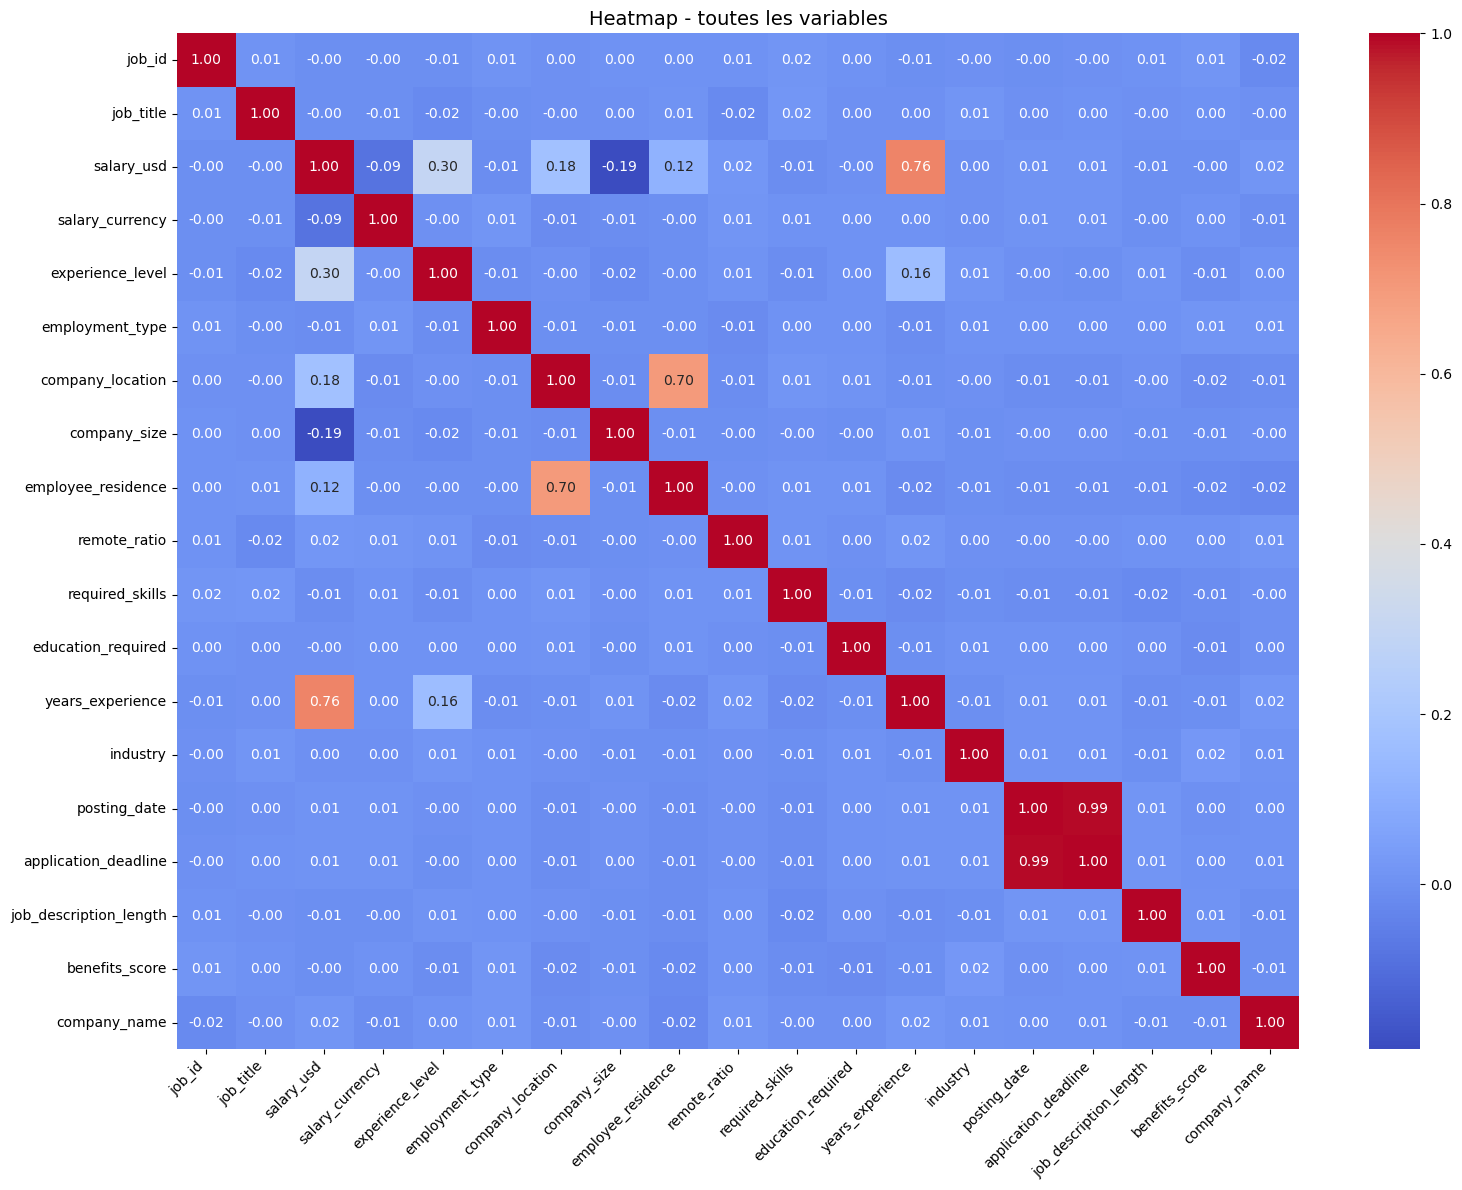

In [3]:
from pandas.plotting import parallel_coordinates
# 1) Chargement des données
#df = pd.read_csv(r"c:\Users\HP\Downloads\ai_job_dataset.csv")

# 2) Encodage des variables qualitatives
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# 3) Heatmap de corrélation
corr = df_encoded.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Heatmap - toutes les variables", fontsize=14)
plt.tight_layout()
plt.show()

🔷 Heatmap de corrélation — Points importants
Permet de visualiser les relations entre toutes les variables simultanément
Chaque cellule représente un coefficient de corrélation entre deux variables
Les valeurs varient entre -1 et +1 :
+1 → forte corrélation positive (les deux variables évoluent ensemble)
-1 → forte corrélation négative (relation inverse)
0 → absence de relation linéaire
Met en évidence les dépendances entre variables
Permet d’identifier des variables fortement liées (clusters de variables)
Aide à détecter la redondance entre variables (variables similaires)
Facilite la compréhension de la structure globale des données
Utile pour la réduction de dimension (suppression de variables corrélées)
Permet d’orienter le choix des variables dans les modèles d’analyse ou de machine learning
Visualisation compacte et intuitive pour analyser les relations multivariées


 Heatmap de corrélation — Points importants

* Permet de visualiser les relations entre **toutes les variables simultanément**
* Chaque cellule représente un **coefficient de corrélation** entre deux variables
* Les valeurs varient entre **-1 et +1** :

  * **+1** → forte corrélation positive (les deux variables évoluent ensemble)
  * **-1** → forte corrélation négative (relation inverse)
  * **0** → absence de relation linéaire
* Met en évidence les **dépendances entre variables**
* Permet d’identifier des **variables fortement liées** (clusters de variables)
* Aide à détecter la **redondance** entre variables (variables similaires)
* Facilite la compréhension de la **structure globale des données**
* Utile pour la **réduction de dimension** (suppression de variables corrélées)
* Permet d’orienter le choix des variables dans les modèles d’analyse ou de machine learning
* Visualisation compacte et intuitive pour analyser les relations multivariées

# 3) Comparer des groupes
## 3.1) Boxplot

Index(['Retail', 'Media', 'Automotive', 'Consulting'], dtype='object', name='industry')


Text(0.5, 1.05, "Comparaison des salaires selon le niveau d'experiance, l'industruie et la taille de l'entreprise\nBoxplot")

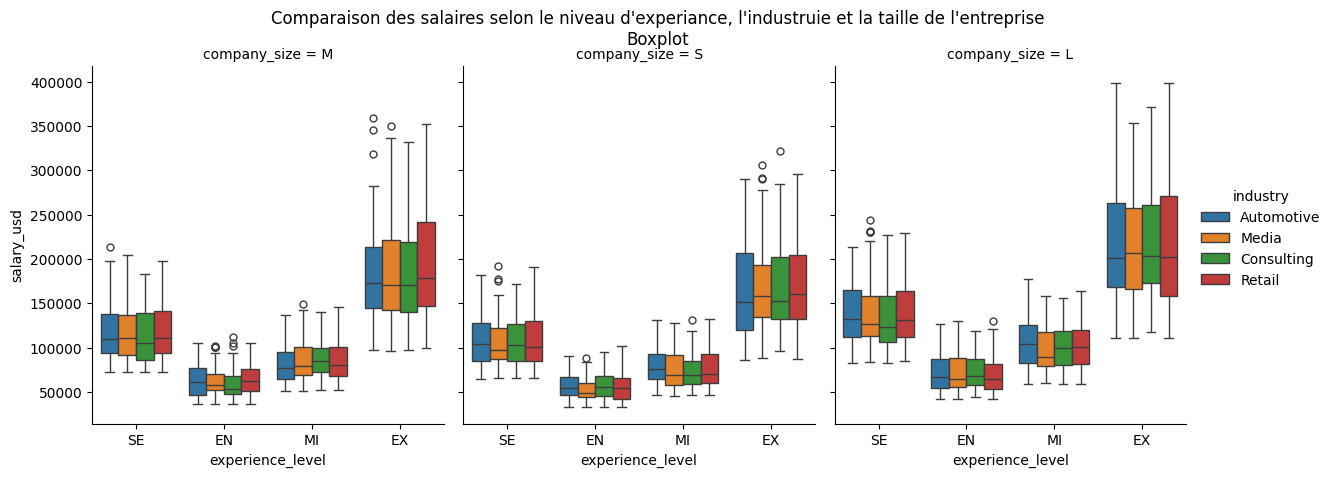

In [21]:
top_industries = df['industry'].value_counts().nlargest(4).index #les 4 industries les plus frequentes
print(top_industries)
df_filtered = df[df['industry'].isin(top_industries)]
f = sns.catplot(
    data=df_filtered,   
    x="experience_level",
    y="salary_usd",
    hue="industry",
    col="company_size",   
    kind="box",
    height=4.5,
    aspect=0.9
)
f.fig.suptitle("Comparaison des salaires selon le niveau d'experiance, l'industruie et la taille de l'entreprise\nBoxplot", y=1.05)

### Interpretation et analyse:
Ce boxplot illustre que les salaires augmentent avec le niveau d’expérience et la taille de l’entreprise, car les profils plus expérimentés apportent davantage de valeur ajoutée et les grandes structures disposent de moyens financiers plus importants pour rémunérer leurs employés. Les différences entre industries traduisent la nature économique de chaque secteur : certains génèrent plus de revenus ou nécessitent des compétences spécialisées, ce qui se reflète dans des salaires plus élevés, tandis que d’autres restent plus modestes. La dispersion observée dans les boxplots montre aussi que, même au sein d’un même niveau d’expérience ou d’une même industrie, les salaires varient selon des facteurs comme la spécialisation, la localisation ou la rareté des compétences. En somme, les résultats s’expliquent par la combinaison de l’expérience, de la taille de l’entreprise et de la dynamique propre à chaque secteur.

## 3.2) Violin plot

Text(0.5, 1.05, "Comparaison des salaires selon le niveau d'experiance, l'industruie et la taille de l'entreprise\nviolin plot")

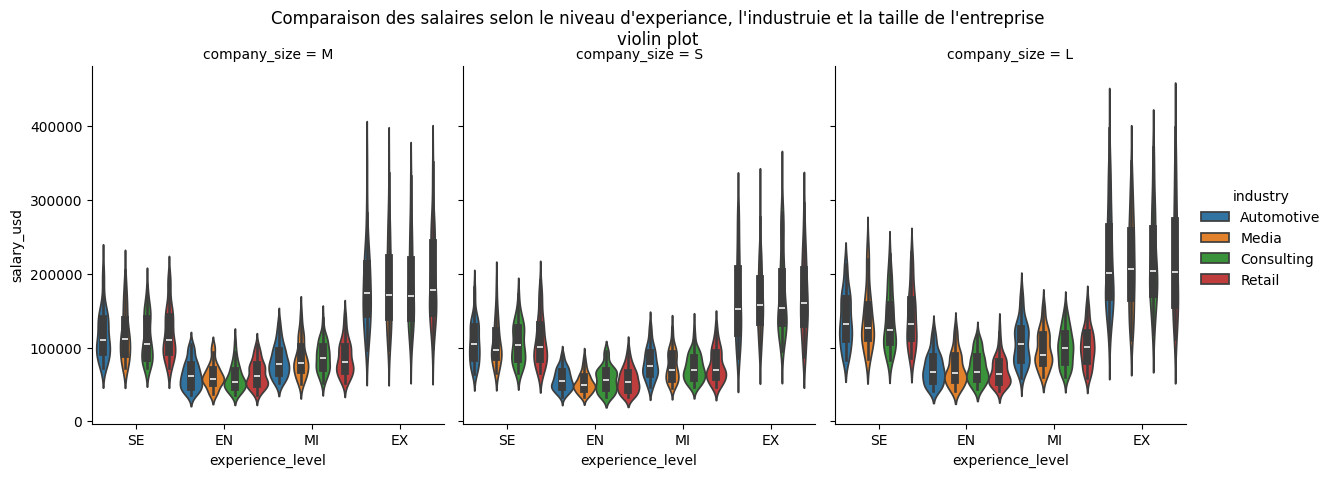

In [22]:
f = sns.catplot(
    data=df_filtered,   
    x="experience_level",
    y="salary_usd",
    hue="industry",
    col="company_size",   
    kind="violin",
    height=4.5,
    aspect=0.9,
    width=1
)

f.fig.suptitle("Comparaison des salaires selon le niveau d'experiance, l'industruie et la taille de l'entreprise\nviolin plot", y=1.05)

### Interpretation et analyse:
Ce violon plot illustre la distribution des salaires en fonction du niveau d’expérience, de l’industrie et de la taille de l’entreprise. On remarque que les salaires tendent à croître avec l’expérience, en particulier pour les profils MI et EX, et que les grandes entreprises (L) présentent des distributions plus étendues et des médianes plus élevées que les petites (S) ou moyennes (M). Les formes des violons montrent aussi la densité des salaires : certaines industries concentrent davantage de valeurs autour de niveaux spécifiques, tandis que d’autres affichent une dispersion plus large. Ces résultats s’expliquent par le fait que l’expérience accroît la valeur des employés, que les grandes entreprises disposent de plus de moyens financiers, et que chaque secteur a ses propres dynamiques économiques, ce qui crée des écarts de rémunération et des distributions distinctes.
## 3.3) les decisions
À partir des deux graphes (boxplot et violon plot), plusieurs décisions peuvent être dégagées. D’abord, il est clair que l’expérience est le facteur le plus déterminant : les profils MI et surtout EX obtiennent des salaires nettement supérieurs, ce qui justifie d’investir dans la formation et la montée en compétences des employés. Ensuite, la taille de l’entreprise influence fortement la rémunération : les grandes entreprises (L) offrent non seulement des salaires plus élevés mais aussi une plus grande variabilité, ce qui traduit davantage d’opportunités et de marges de négociation. Enfin, les industries présentent des comportements distincts, certaines concentrant les salaires autour de valeurs spécifiques, d’autres montrant une dispersion plus large, ce qui suggère que le choix du secteur est stratégique pour maximiser ses perspectives salariales. En résumé, les résultats orientent vers trois décisions clés : valoriser l’expérience, cibler les grandes entreprises pour une meilleure rémunération, et choisir l’industrie en fonction de ses objectifs financiers et professionnels.


# 4) Analyse des profils multivariés 
## 4.1) Parallel coordinates

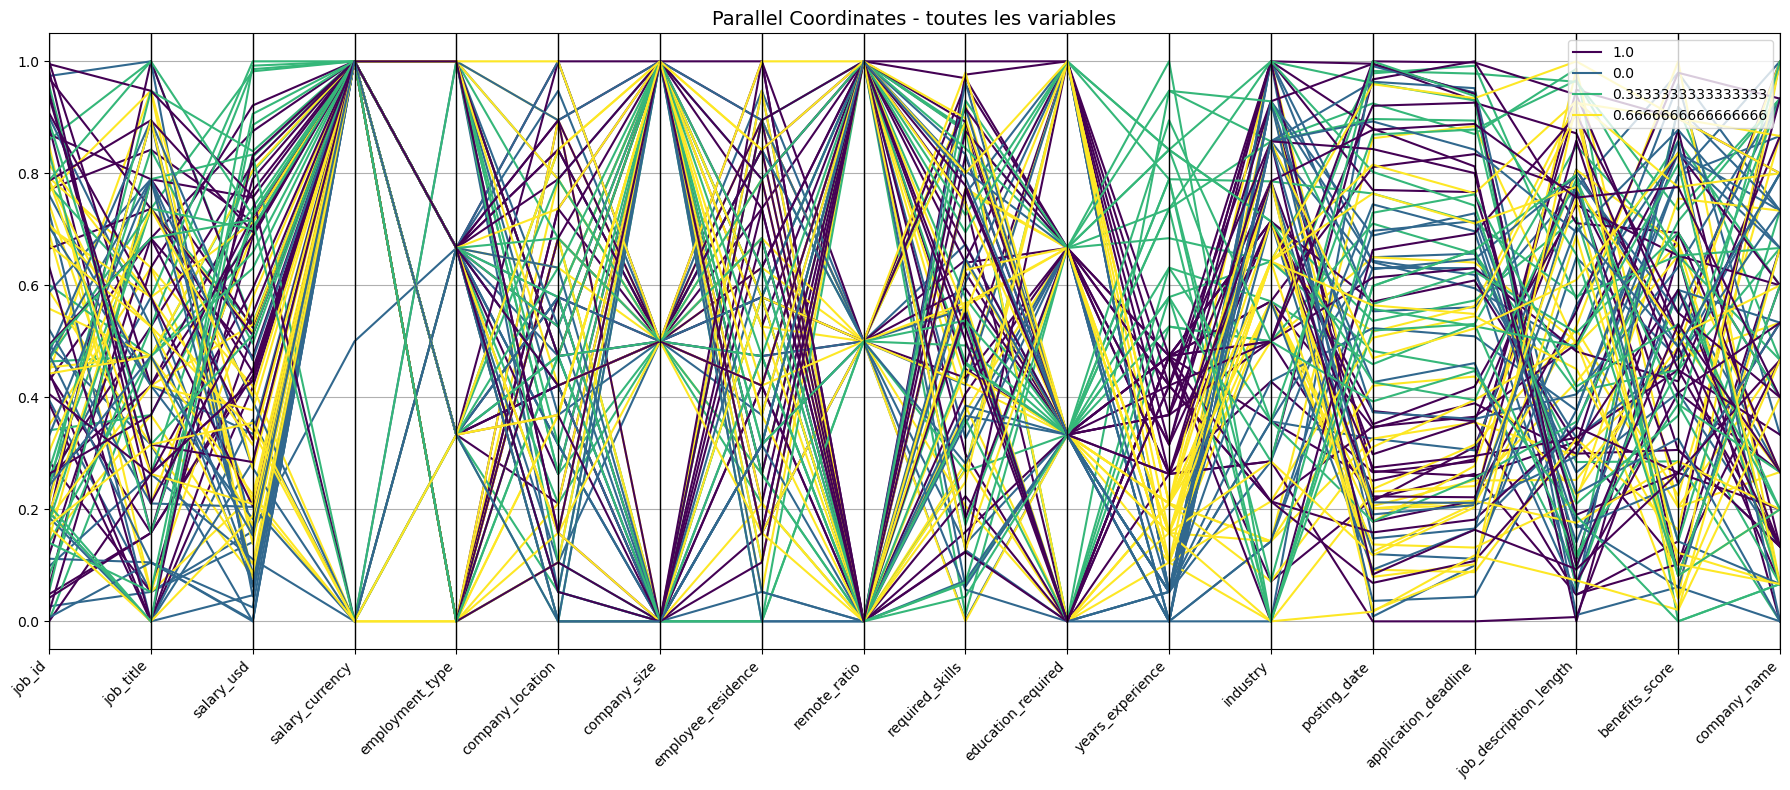

In [4]:
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

# Chargement des données
#df = pd.read_csv(r"c:\Users\HP\Downloads\ai_job_dataset.csv")

# Préparation des données
df_parallel = df.copy()

# Encodage des variables qualitatives
for col in df_parallel.columns:
    df_parallel[col] = df_parallel[col].astype('category').cat.codes

# Réduction de taille pour lisibilité
df_parallel = df_parallel.sample(100, random_state=42)

# Normalisation
scaler = MinMaxScaler()
df_parallel[df_parallel.columns] = scaler.fit_transform(df_parallel)

# Parallel Coordinates
target = 'experience_level' 

plt.figure(figsize=(18,8))

parallel_coordinates(df_parallel, target, colormap='viridis')

plt.xticks(rotation=45, ha='right')
plt.title("Parallel Coordinates - toutes les variables", fontsize=14)

plt.tight_layout()
plt.show()

 Parallel Coordinates — Points importants

* Permet de visualiser des **données multivariées** (plusieurs variables à la fois)
* Chaque ligne représente une **observation (individu)**
* Chaque axe vertical correspond à une **variable**
* Les lignes relient les valeurs d’un même individu sur toutes les variables
* Permet d’analyser les **profils individuels** dans un espace multidimensionnel
* Facilite la **comparaison entre groupes** (ex: `experience_level`)
* Les lignes proches indiquent des **observations similaires**
* Les lignes qui se croisent beaucoup indiquent des **différences importantes entre profils**
* Permet de détecter des **patterns, tendances et regroupements**
* Met en évidence les **relations et interactions entre variables**
* Utile pour identifier des **structures cachées** dans les données
* Aide à comprendre comment plusieurs variables influencent simultanément une observation
* Représentation adaptée pour explorer des données complexes multidimensionnelles

## 4.2) Décision de 2) et 4)
En termes de prise de décision, l’analyse met en évidence un marché caractérisé par une complexité importante et une faible structuration globale. Les variables apparaissent majoritairement indépendantes, tandis que les profils observés présentent une grande diversité, sans segmentation claire. Dans ce contexte, il devient difficile d’établir des décisions générales ou des règles simples. Il est donc plus pertinent de recourir à des approches analytiques avancées, telles que la segmentation ou les techniques de machine learning, afin d’identifier des groupes homogènes et d’améliorer la compréhension des comportements sous-jacents.

# 5) Reduction de dimension

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [24]:
skills_exploded = df["required_skills"].str.split(",").explode().str.strip()

# Compter les occurrences de chaque compétence
top10 = skills_exploded.value_counts().head(4).index.tolist()
print(top10)

['Python', 'SQL', 'TensorFlow', 'Kubernetes']


In [25]:
def get_main_skill(skill_list):
    skills = [s.strip() for s in skill_list.split(",")]
    for skill in skills:
        if skill in top10:
            return skill  # retourne la 1ère compétence qui est dans le top10
    return "other"

df["main_skill"] = df["required_skills"].apply(get_main_skill)

Variance expliquée : [0.34766748 0.20194878]


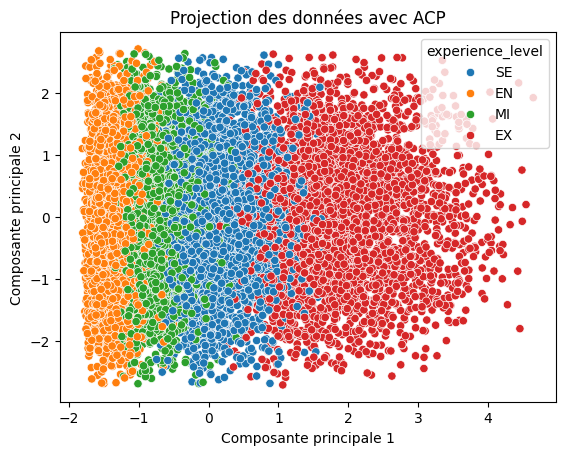


Contribution des variables :
     salary_usd  remote_ratio  years_experience  job_description_length  \
PC1    0.706711      0.027683          0.706758               -0.015794   
PC2    0.002293      0.485567         -0.001956                0.636839   

     benefits_score  
PC1       -0.006047  
PC2        0.598875  


In [27]:
numerical_columns = [var for var in df.select_dtypes(include='number').columns]

X =df[numerical_columns]


#  Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# . ACP (2 composantes)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
# . DataFrame PCA
df_pca = pd.DataFrame(components, columns=["PC1","PC2"])
df_pca["experience_level"] = df["experience_level"]

# . Variance expliquée
print("Variance expliquée :", pca.explained_variance_ratio_)

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="experience_level",
   
)

plt.title("Projection des données avec ACP")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.show()


#  Contribution des variables
contributions_vars = pd.DataFrame(
    pca.components_,
    columns=numerical_columns,
    index=["PC1","PC2"]
)

print("\nContribution des variables :")
print(contributions_vars)



# 5.1) Interprétation des composantes


PC1 — "Axe de valeur professionnelle"
Les deux variables qui dominent PC1 sont salary_usd (0.707) et years_experience (0.707) — des coefficients quasiment identiques et très élevés. PC1 mesure donc la progression de carrière : plus un profil est à droite sur le graphique, plus il est expérimenté et mieux payé. C'est ce qui explique la séparation parfaite EN → MI → SE → EX de gauche à droite.

PC2 — "Axe de conditions de travail"
PC2 est dominé par remote_ratio (0.486), job_description_length (0.637) et benefits_score (0.599). Il capture la qualité et la flexibilité du poste : télétravail, avantages sociaux, richesse de l'offre. Ce n'est pas lié au niveau d'expérience, d'où le mélange vertical des couleurs.


L'ACP réduit nos 5 variables numériques en 2 axes qui expliquent 55% de la variance totale. Le premier axe oppose les profils juniors aux profils exécutifs via le salaire et l'expérience. Le second axe reflète la qualité des conditions de travail, indépendamment du niveau de séniorité.

# 5.2) Décisions concrètes

Pour le recrutement :

Segmenter les offres en 2 dimensions indépendantes : niveau de séniorité (PC1) ET qualité du poste (PC2). Un poste Executive avec peu d'avantages est différent d'un poste Entry avec beaucoup de télétravail.

Pour la stratégie salariale :

salary_usd et years_experience sont quasi-parfaitement corrélés (même poids sur PC1). Toute politique salariale doit donc être strictement indexée sur l'expérience — les anomalies sont facilement détectables sur le graphique (points mal positionnés par rapport à leur couleur).

Pour l'attractivité des offres :

PC2 montre que remote_ratio, benefits_score et job_description_length forment un bloc cohérent. Pour attirer des candidats sans augmenter les salaires, il faut jouer sur ces 3 leviers ensemble — une offre bien rédigée, avec du télétravail et de bons avantages.

# 5.3) 3 dimensions

Variance expliquée : [0.34766748 0.20194878 0.19931709]


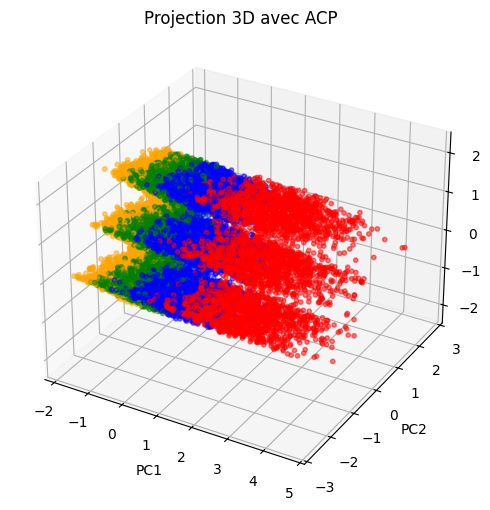


Contribution des variables :
     salary_usd  remote_ratio  years_experience  job_description_length  \
PC1    0.706711      0.027683          0.706758               -0.015794   
PC2    0.002293      0.485567         -0.001956                0.636839   
PC3   -0.023848      0.832856         -0.016271               -0.129719   

     benefits_score  
PC1       -0.006047  
PC2        0.598875  
PC3       -0.537299  


In [30]:
#ACP (3 composantes)

pca = PCA(3)
pca.fit(X_scaled)

# Variance expliquée
print("Variance expliquée :", pca.explained_variance_ratio_)
X_pca = pca.fit_transform(X_scaled)

# ===== Plot 3D =====
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
colors = {"EN":"orange", "MI":"green", "SE":"blue", "EX":"red"}
c = df["experience_level"].map(colors)

ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],c=c, alpha=0.5, s=10)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Projection 3D avec ACP")

plt.show()

# Contribution des variables
contributions_vars = pd.DataFrame(
    pca.components_,
    columns=numerical_columns,
    index=["PC1","PC2", "PC3"]
)

print("\nContribution des variables :")
print(contributions_vars)

Ce que le graphique montre
Sur PC1 (axe horizontal gauche-droite) :
La séparation par couleur est parfaite : 

🟠  OrangeEN (Entry)Gauche −2 à 0
🟢 VertMI (Mid)Centre −1 à 1
🔵 BleuSE (Senior)Centre-droit 0 à 2
🔴 RougeEX (Executive)Droite 2 à 5

Sur PC2 (axe profondeur) :
Les 4 groupes se superposent verticalement — l'expérience ne prédit pas la qualité du poste. Un Entry peut avoir autant d'avantages qu'un Executive.
Sur PC3 (axe vertical haut-bas) :
Les nuages sont plats et empilés — PC3 (télétravail vs benefits) est aussi indépendant du niveau d'expérience

Interprétation globale pour ta présentation

"Les 3 composantes confirment que le marché de l'emploi data se structure autour de 3 dimensions totalement indépendantes :

PC1 : Qui es-tu ? (séniorité + salaire)
PC2 : Dans quel poste ? (qualité, benefits, description)
PC3 : Comment travailles-tu ? (télétravail vs avantages)

Un Executive en présentiel avec peu d'avantages et un Entry en full remote avec un bon package sont deux réalités du marché qui coexistent sans se contredire."

Décision stratégique finale
Pour une entreprise qui recrute :

Ne pas confondre les 3 axes — augmenter le salaire (PC1) ne compense pas un manque de télétravail (PC3)
Chaque levier est indépendant et doit être piloté séparément

Pour un candidat :

Négocier sur les 3 dimensions : titre/salaire ET conditions ET flexibilité
Un poste fort sur PC1 mais faible sur PC2 et PC3 reste un mauvais deal

